# Anomally Detection : Manual vs Automatic (sklearn)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.datasets import make_blobs

np.random.seed(42)

## Create Random data

In [7]:
#The underscore _ ignores the labels returned by make_blobs, since we’ll create our own labels later.
X_normal , _ = make_blobs(n_samples=300,centers=[[2,2],[-2,-2]],cluster_std=0.8,random_state=42) 
X_anomalies = np.random.uniform(low=-8, high=8, size=(25, 2))

X = np.vstack([X_normal, X_anomalies])

#Assign label 0 to normal data (300 samples).
#Assign label 1 to anomaly data (25 samples).
y_true = np.array([0] * len(X_normal) + [1] * len(X_anomalies)) 

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y_true, test_size=0.4,random_state=42, stratify=y_true) # Stratify for uniform split

print(f"Total data shape: {X.shape}")
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Validation data shape (X_val): {X_val.shape}")
print(f"Validation labels (anomalies): {np.sum(y_val)} out of {len(y_val)}")

Total data shape: (325, 2)
Training data shape (X_train): (195, 2)
Validation data shape (X_val): (130, 2)
Validation labels (anomalies): 10 out of 130


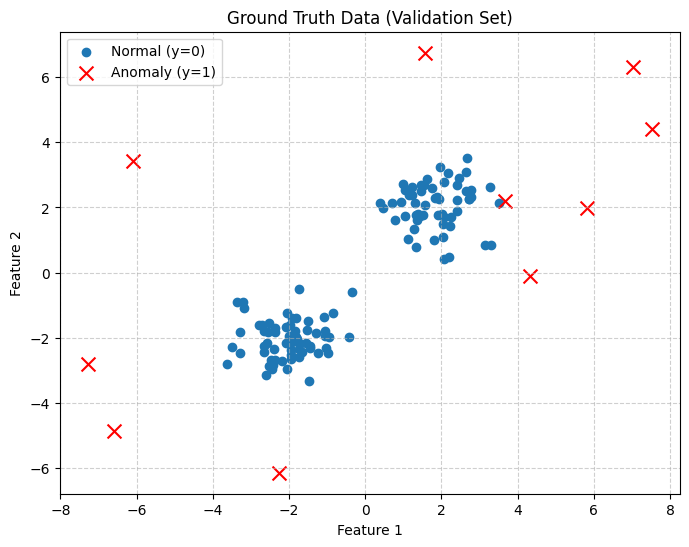

In [9]:
plt.figure(figsize=(8, 6))
plt.title("Ground Truth Data (Validation Set)")
plt.scatter(X_val[y_val==0, 0], X_val[y_val==0, 1], label="Normal (y=0)")
plt.scatter(X_val[y_val==1, 0], X_val[y_val==1, 1], label="Anomaly (y=1)", 
            marker='x', c='r', s=100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Manual gaussian method

In [12]:
# Calculate mean and variance
def estimate_gaussian(X): 

    m,n = X.shape
    mu = 1/m * np.sum(X,axis=0)
    var = 1/m * np.sum((X-mu)**2,axis = 0)
    return mu,var


# Calculate probability density function for each example
def calculate_pdf(X,mu,var):

    m,n = X.shape
    p = np.ones(m)
    for i in range(n):
        p *= norm.pdf(X[:,i],mu[i],np.sqrt(var[i]))
    return p 

def select_threshold(y_val , p_val):

    best_epsilon = 0
    best_F1 = 0    
    F1= 0

    epsilon_safety = 1e-9
    step_size = (max(p_val) - min(p_val))/1000

    for epsilon in np.arange(min(p_val),max(p_val),step_size):

        predictions = (p_val < epsilon)

        tp = np.sum((predictions == 1) & (y_val==1))
        fp = np.sum((predictions == 1) & (y_val==0))
        fn = np.sum((predictions == 0) & (y_val==1))

        prec = tp / (tp + fp + epsilon_safety)
        rec = tp / (tp + fn + epsilon_safety)

        F1 = 2 * prec * rec / (prec + rec + epsilon_safety)

        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon

    return best_epsilon, best_F1        

In [13]:
mu, var = estimate_gaussian(X_train)
print("Calculated mean : ",mu)
print("Calculated variance : ",var)

p_val_manual = calculate_pdf(X_val,mu,var)

epsilon_manual, f1_manual = select_threshold(y_val,p_val_manual)
print(f"  Best Epsilon: {epsilon_manual:e}")
print(f"  Best F1 (from select_threshold): {f1_manual:.4f}")

y_pred_manual = (p_val_manual < epsilon_manual).astype(int)

Calculated mean :  [ 0.026397   -0.04347455]
Calculated variance :  [6.19771789 6.01993994]
  Best Epsilon: 5.864667e-03
  Best F1 (from select_threshold): 0.9091


## Automatic sklearn models

In [14]:
iso_model = IsolationForest(contamination='auto', random_state=42)
iso_model.fit(X_train)

p_val_if = iso_model.decision_function(X_val)

epsilon_if, f1_if = select_threshold(y_val, p_val_if)
print(f"  Best Threshold (Score): {epsilon_if:.4f}")
print(f"  Best F1 (from select_threshold): {f1_if:.4f}")

y_pred_if = (p_val_if < epsilon_if).astype(int)

  Best Threshold (Score): -0.0621
  Best F1 (from select_threshold): 0.9474


In [15]:
svm_model = OneClassSVM(nu=0.1,kernel='rbf',gamma='auto')
svm_model.fit(X_train)

p_val_svm = svm_model.decision_function(X_val)

epsilon_svm, f1_svm = select_threshold(y_val, p_val_svm)
print(f"  Best Threshold (Score): {epsilon_svm:.4f}")
print(f"  Best F1 (from select_threshold): {f1_svm:.4f}")

y_pred_svm = (p_val_svm < epsilon_svm).astype(int)

  Best Threshold (Score): -0.2338
  Best F1 (from select_threshold): 0.9474


In [17]:
print("---" * 15)
print("PERFORMANCE METRICS (on Validation Set)")
print("---" * 15)

print("\nMethod 1: Manual Gaussian Model")
print(classification_report(y_val, y_pred_manual, target_names=["Normal (0)", "Anomaly (1)"]))

print("\nMethod 2: Isolation Forest")
print(classification_report(y_val, y_pred_if, target_names=["Normal (0)", "Anomaly (1)"]))

print("\nMethod 3: One-Class SVM")
print(classification_report(y_val, y_pred_svm, target_names=["Normal (0)", "Anomaly (1)"]))

---------------------------------------------
PERFORMANCE METRICS (on Validation Set)
---------------------------------------------

Method 1: Manual Gaussian Model
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99       120
 Anomaly (1)       0.83      1.00      0.91        10

    accuracy                           0.98       130
   macro avg       0.92      0.99      0.95       130
weighted avg       0.99      0.98      0.99       130


Method 2: Isolation Forest
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      1.00       120
 Anomaly (1)       1.00      0.90      0.95        10

    accuracy                           0.99       130
   macro avg       1.00      0.95      0.97       130
weighted avg       0.99      0.99      0.99       130


Method 3: One-Class SVM
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      1.00       120
 Anomaly (1)       

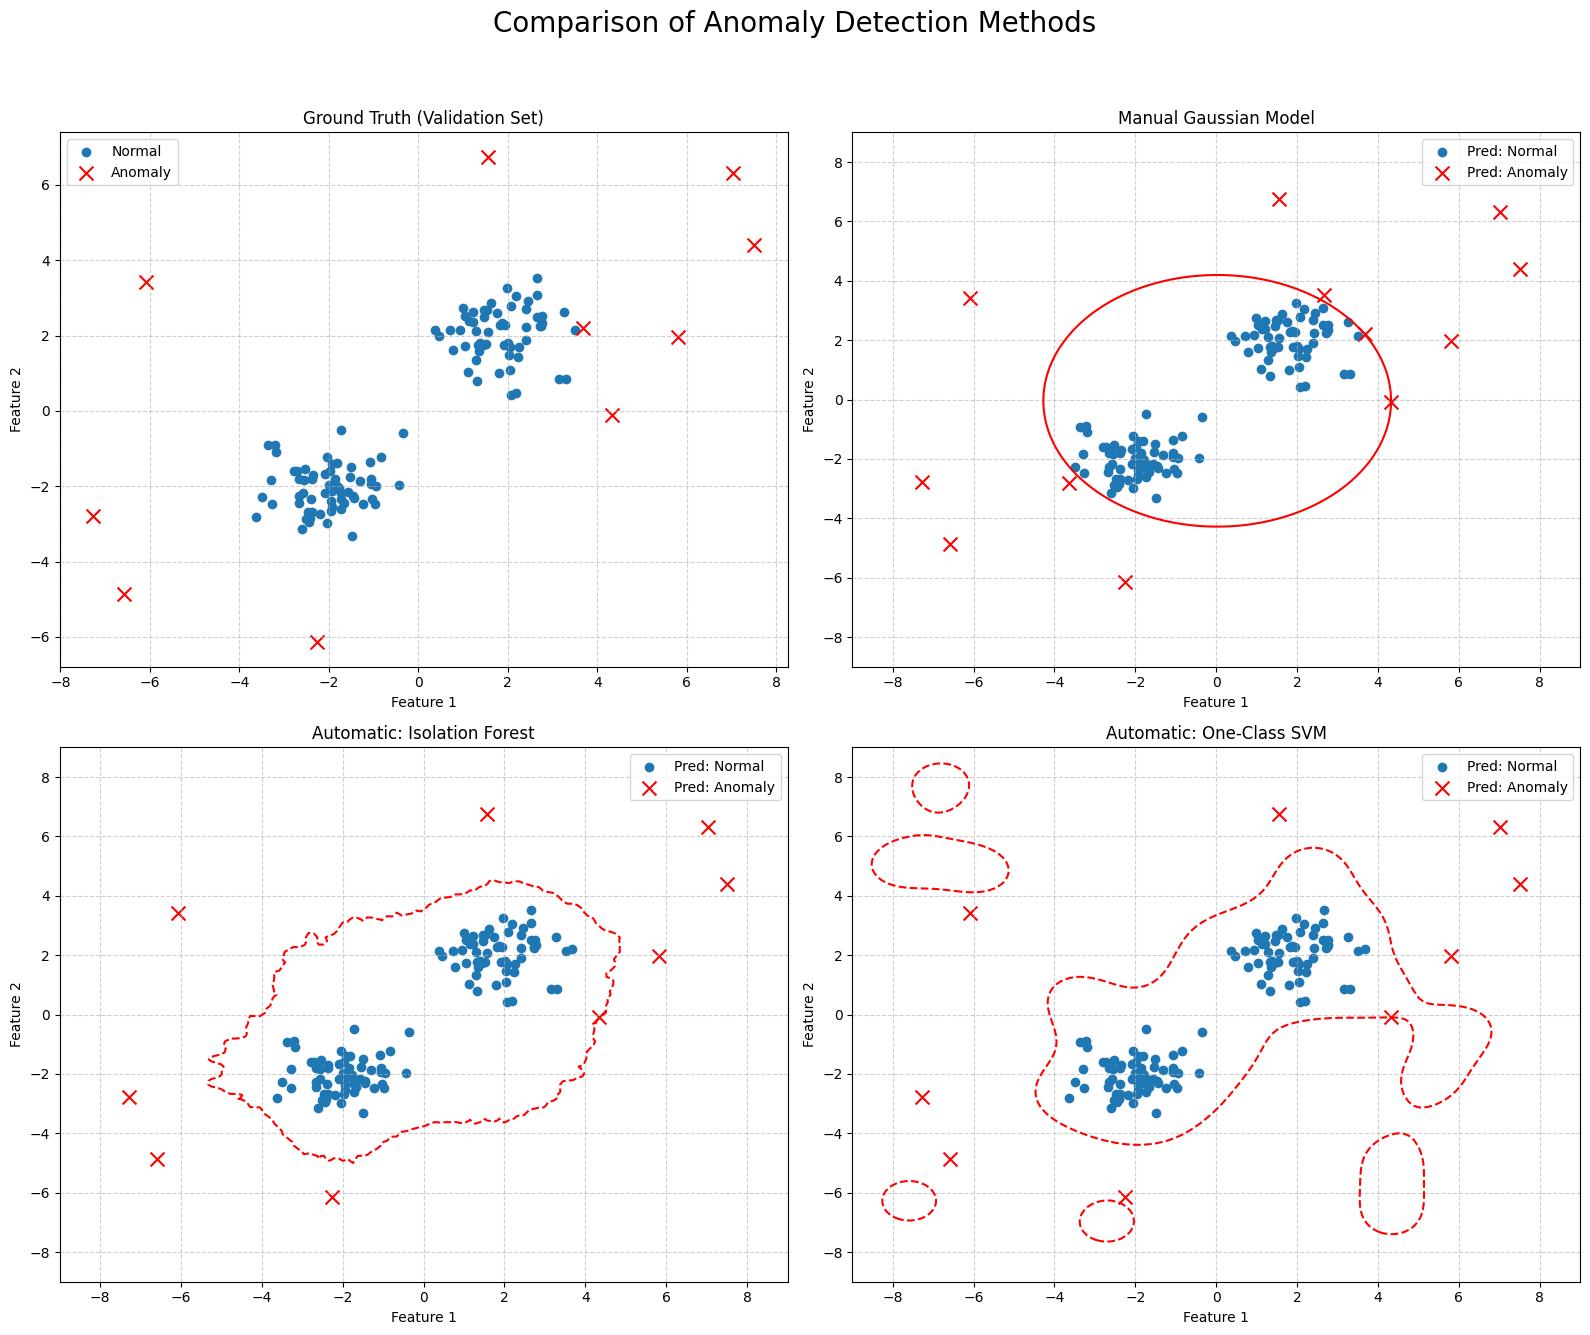

In [19]:
# Create a mesh grid to plot decision boundaries
xx, yy = np.meshgrid(np.linspace(-9, 9, 150),
                       np.linspace(-9, 9, 150))
X_grid = np.c_[xx.ravel(), yy.ravel()]

# Get the scores for the whole grid
Z_manual = calculate_pdf(X_grid, mu, var).reshape(xx.shape)
Z_if = iso_model.decision_function(X_grid).reshape(xx.shape)
Z_svm = svm_model.decision_function(X_grid).reshape(xx.shape)

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Comparison of Anomaly Detection Methods', fontsize=20)

# --- Plot 1: Ground Truth ---
axes[0, 0].set_title("Ground Truth (Validation Set)")
axes[0, 0].scatter(X_val[y_val==0, 0], X_val[y_val==0, 1], label="Normal")
axes[0, 0].scatter(X_val[y_val==1, 0], X_val[y_val==1, 1], label="Anomaly", 
                   marker='x', c='r', s=100)
axes[0, 0].legend()

# --- Plot 2: Manual Gaussian ---
axes[0, 1].set_title("Manual Gaussian Model")
# Plot the decision boundary (contour)
axes[0, 1].contour(xx, yy, Z_manual, levels=[epsilon_manual], colors='red')
# Plot the predictions
axes[0, 1].scatter(X_val[y_pred_manual==0, 0], X_val[y_pred_manual==0, 1], 
                   label="Pred: Normal")
axes[0, 1].scatter(X_val[y_pred_manual==1, 0], X_val[y_pred_manual==1, 1], 
                   label="Pred: Anomaly", marker='x', c='r', s=100)
axes[0, 1].legend()

# --- Plot 3: Isolation Forest ---
axes[1, 0].set_title("Automatic: Isolation Forest")
axes[1, 0].contour(xx, yy, Z_if, levels=[epsilon_if], colors='red')
axes[1, 0].scatter(X_val[y_pred_if==0, 0], X_val[y_pred_if==0, 1], 
                   label="Pred: Normal")
axes[1, 0].scatter(X_val[y_pred_if==1, 0], X_val[y_pred_if==1, 1], 
                   label="Pred: Anomaly", marker='x', c='r', s=100)
axes[1, 0].legend()

# --- Plot 4: One-Class SVM ---
axes[1, 1].set_title("Automatic: One-Class SVM")
axes[1, 1].contour(xx, yy, Z_svm, levels=[epsilon_svm], colors='red')
axes[1, 1].scatter(X_val[y_pred_svm==0, 0], X_val[y_pred_svm==0, 1], 
                   label="Pred: Normal")
axes[1, 1].scatter(X_val[y_pred_svm==1, 0], X_val[y_pred_svm==1, 1], 
                   label="Pred: Anomaly", marker='x', c='r', s=100)
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()